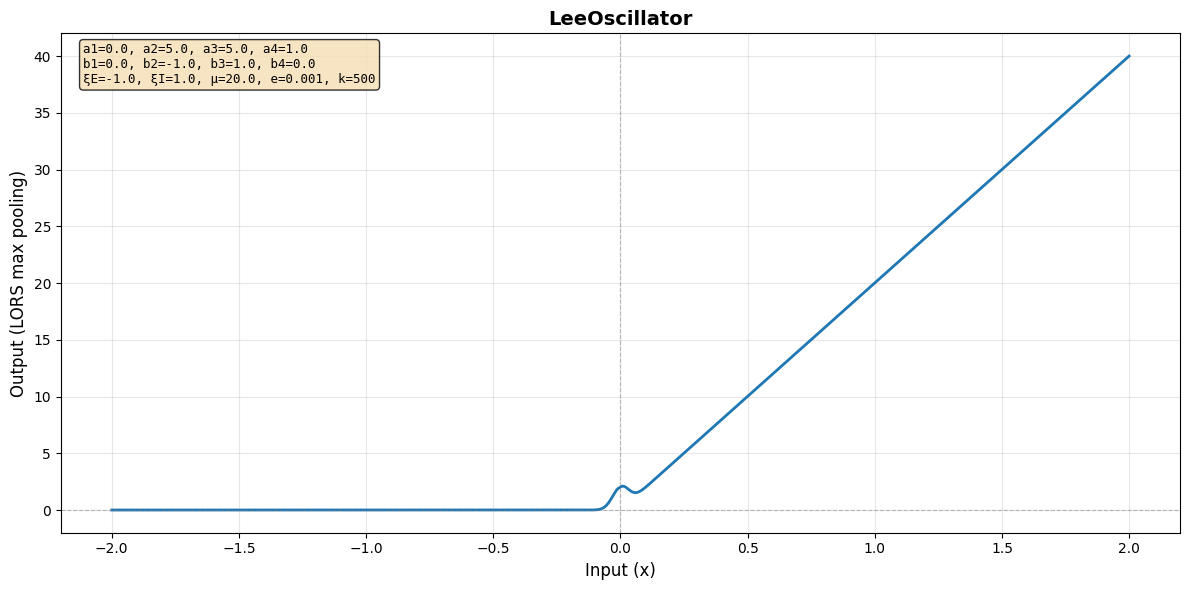

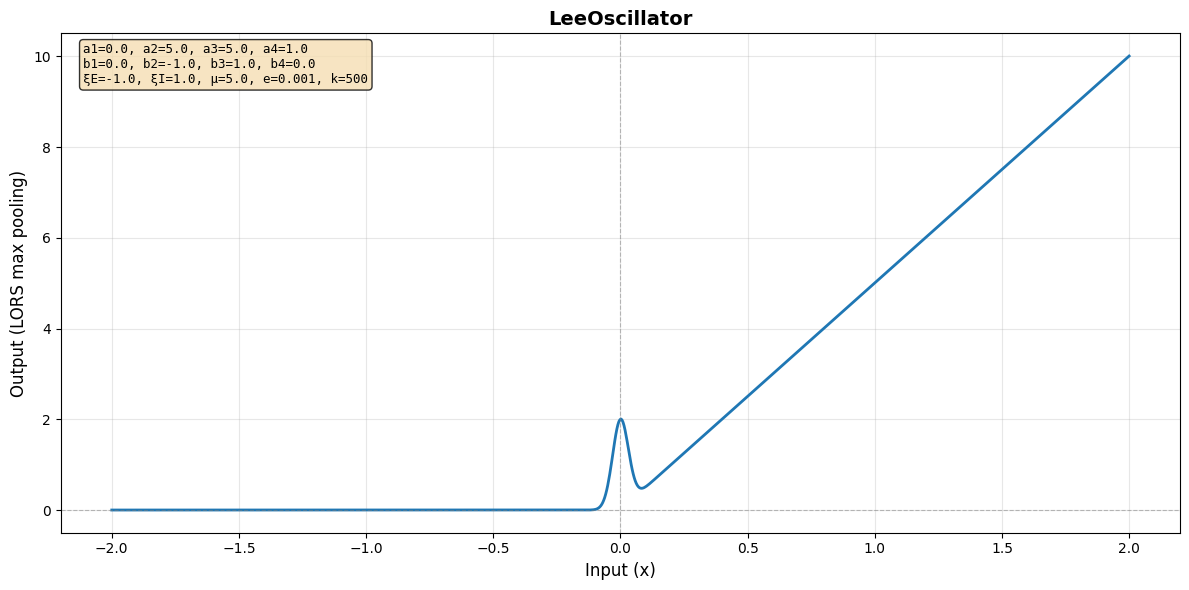

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def run_lors(x, a1, a2, a3, a4, b1, b2, b3, b4, xi_E, xi_I, mu, e, k, N=101):
    """
    运行LORS振荡器，返回max pooling后的输出
    """
    orig_shape = x.shape
    device = x.device
    x_flat = x.view(-1)
    B = x_flat.size(0)

    results = torch.zeros(B, N, device=device)

    for i, inp in enumerate(x_flat):
        E = torch.zeros(N, device=device)
        I = torch.zeros(N, device=device)
        LORS = torch.zeros(N, device=device)
        Omega = torch.zeros(N, device=device)

        # 初始化 t=0
        E[0], LORS[0], Omega[0] = 0.2, 0.2, 0.0
        sim0 = inp + e * torch.sign(inp)

        for t in range(N - 1):
            E[t+1] = torch.tanh(mu * (a1 * LORS[t] + a2 * E[t] - a3 * I[t] + a4 * sim0 - xi_E))
            I[t+1] = torch.tanh(mu * (b1 * LORS[t] - b2 * E[t] - b3 * I[t] + b4 * sim0 - xi_I))
            # Omega[t+1] = torch.tanh(mu * sim0)
            Omega[t+1] = torch.relu(mu * sim0)
            LORS[t+1] = (E[t+1] - I[t+1]) * torch.exp(-k * sim0 * sim0) + Omega[t+1]

        results[i] = LORS

    # 丢弃t=0，对t=1~100做max pooling
    seq = results[..., 1:]
    output = seq.max(dim=-1).values

    return output.view(*orig_shape)


def visualize_lee_oscillator(
        a1, a2, a3, a4,
        b1, b2, b3, b4,
        xi_E, xi_I, mu, e, k,
        x_min=-2.0,
        x_max=2.0,
        n_points=1000):
    """
    可视化 LeeOscillator 的激活函数
    """
    # 生成输入点
    x = torch.linspace(x_min, x_max, n_points)

    # 计算输出
    with torch.no_grad():
        y = run_lors(x, a1, a2, a3, a4, b1, b2, b3, b4, xi_E, xi_I, mu, e, k)

    # 转换为numpy
    x_np = x.numpy()
    y_np = y.numpy()

    # 绘图
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(x_np, y_np, linewidth=2, color='#1f77b4')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    ax.set_xlabel('Input (x)', fontsize=12)
    ax.set_ylabel('Output (LORS max pooling)', fontsize=12)
    ax.set_title('LeeOscillator', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # 参数信息
    param_text = f'a1={a1}, a2={a2}, a3={a3}, a4={a4}\n'
    param_text += f'b1={b1}, b2={b2}, b3={b3}, b4={b4}\n'
    param_text += f'ξE={xi_E}, ξI={xi_I}, μ={mu}, e={e}, k={k}'

    ax.text(0.02, 0.98, param_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

    return x_np, y_np


if __name__ == "__main__":
    # ========== 参数设置 ==========
    # param1 参数
    a1, a2, a3, a4 = 0.0, 5.0, 5.0, 1.0
    b1, b2, b3, b4 = 0.0, -1.0, 1.0, 0.0
    xi_E, xi_I, mu, e, k = -1.0, 1.0, 20.0, 0.001, 500

    x_min = -2.0
    x_max = 2.0
    n_points = 1000
    # ==============================

    visualize_lee_oscillator(
        a1, a2, a3, a4,
        b1, b2, b3, b4,
        xi_E, xi_I, mu, e, k,
        x_min=x_min,
        x_max=x_max,
        n_points=n_points
    )

     # ========== 参数设置 ==========
    # param1 参数
    a1, a2, a3, a4 = 0.0, 5.0, 5.0, 1.0
    b1, b2, b3, b4 = 0.0, -1.0, 1.0, 0.0
    xi_E, xi_I, mu, e, k = -1.0, 1.0, 5.0, 0.001, 500

    x_min = -2.0
    x_max = 2.0
    n_points = 1000
    # ==============================

    visualize_lee_oscillator(
        a1, a2, a3, a4,
        b1, b2, b3, b4,
        xi_E, xi_I, mu, e, k,
        x_min=x_min,
        x_max=x_max,
        n_points=n_points
    )


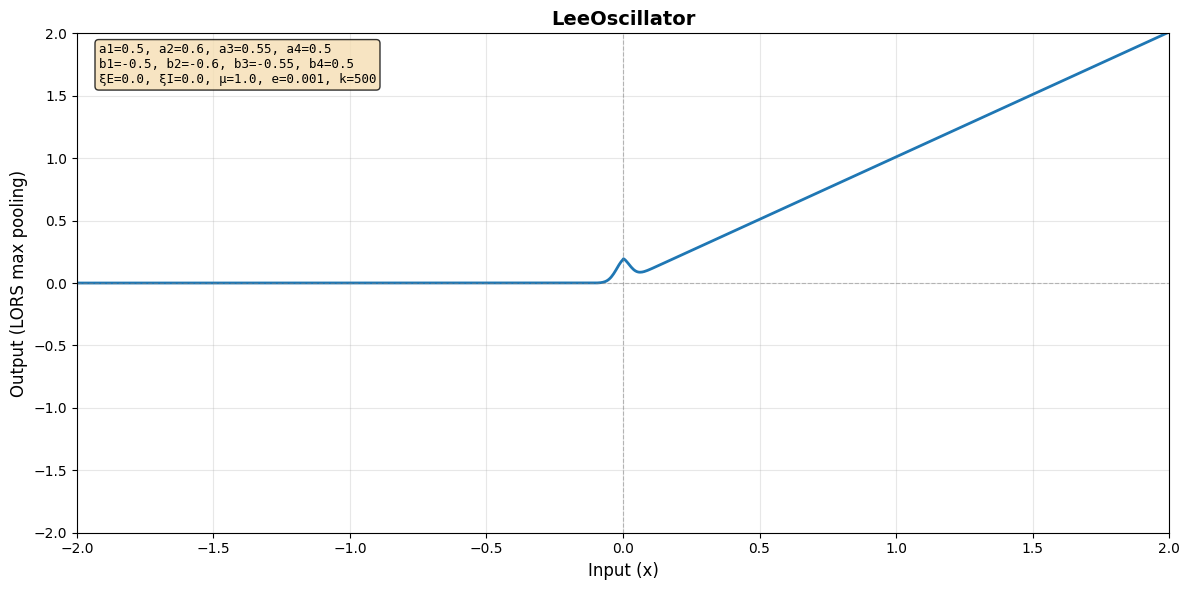

In [52]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def run_lors(x, a1, a2, a3, a4, b1, b2, b3, b4, xi_E, xi_I, mu, e, k, N=101):
    """
    运行LORS振荡器，返回max pooling后的输出
    """
    orig_shape = x.shape
    device = x.device
    x_flat = x.view(-1)
    B = x_flat.size(0)

    results = torch.zeros(B, N, device=device)

    for i, inp in enumerate(x_flat):
        E = torch.zeros(N, device=device)
        I = torch.zeros(N, device=device)
        LORS = torch.zeros(N, device=device)
        Omega = torch.zeros(N, device=device)

        # 初始化 t=0
        E[0], LORS[0], Omega[0] = 0.2, 0.2, 0.0
        sim0 = inp + 10 * e * torch.sign(inp)
        # sim0 = inp
        for t in range(N - 1):
            E[t+1] = torch.tanh(mu * (a1 * LORS[t] + a2 * E[t] - a3 * I[t] + a4 * sim0 - xi_E))
            I[t+1] = torch.tanh(mu * (b1 * LORS[t] - b2 * E[t] - b3 * I[t] + b4 * sim0 - xi_I))
            # Omega[t+1] = torch.tanh(mu * sim0)
            Omega[t+1] = torch.relu(mu * sim0)
            LORS[t+1] = (E[t+1] - I[t+1]) * torch.exp(-k * sim0 * sim0) + Omega[t+1]

        results[i] = LORS

    # 丢弃t=0，取最后一个时间步的值
    output = results[..., -1]

    return output.view(*orig_shape)


def visualize_lee_oscillator(
        a1, a2, a3, a4,
        b1, b2, b3, b4,
        xi_E, xi_I, mu, e, k,
        x_min=-2.0,
        x_max=2.0,
        y_min=-2.0,
        y_max=2.0,
        n_points=1000,
        N=101):
    """
    可视化 LeeOscillator 的激活函数
    """
    # 生成输入点
    x = torch.linspace(x_min, x_max, n_points)

    # 计算输出
    with torch.no_grad():
        y = run_lors(x, a1, a2, a3, a4, b1, b2, b3, b4, xi_E, xi_I, mu, e, k, N=N)

    # 转换为numpy
    x_np = x.numpy()
    y_np = y.numpy()

    # 绘图
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(x_np, y_np, linewidth=2, color='#1f77b4')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    # 固定坐标轴范围
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel('Input (x)', fontsize=12)
    ax.set_ylabel('Output (LORS max pooling)', fontsize=12)
    ax.set_title('LeeOscillator', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # 参数信息
    param_text = f'a1={a1}, a2={a2}, a3={a3}, a4={a4}\n'
    param_text += f'b1={b1}, b2={b2}, b3={b3}, b4={b4}\n'
    param_text += f'ξE={xi_E}, ξI={xi_I}, μ={mu}, e={e}, k={k}'

    ax.text(0.02, 0.98, param_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

    return x_np, y_np


if __name__ == "__main__":
    # ========== 参数设置 ==========
    # param1 参数
    a1, a2, a3, a4 = 0.5, 0.6, 0.55, 0.5
    b1, b2, b3, b4 = -0.5, -0.6, -0.55, 0.5
    xi_E, xi_I, mu, e, k = 0.0, 0.0, 1.0, 0.001, 500

# 0.5, 0.6, 0.55, 0.5, -0.5, -0.6, -0.55, 0.5, 0.0, 0.0, 1.0, 0.001, 50 parm3

    x_min = -2.0
    x_max = 2.0
    y_min = -2.0
    y_max = 2.0
    n_points = 1000
    N = 2  # LORS运行步数
    # ==============================

    visualize_lee_oscillator(
        a1, a2, a3, a4,
        b1, b2, b3, b4,
        xi_E, xi_I, mu, e, k,
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        n_points=n_points,
        N=N
    )
